# CoastalPulse — Weather Indicator EDA

Exploratory data analysis of the Silver-layer hourly dataset: **temperature,
rainfall, humidity, wind speed, and atmospheric pressure** (the five
indicators named in the course's General Tasks), plus the marine-specific
indicators relevant to this team's assigned direction (Option 4: Marine and
Coastal Weather Analytics) — wave height, swell, and sea level.

Data source: `silver_hourly` in Supabase, 15 Sri Lankan coastal locations,
hourly observations from 2025-01-01 to 2026-06-30 (fetched from Open-Meteo's
Marine, Historical Weather, and Air Quality APIs — see
`pipeline/fetch_data.py`).

This notebook is regenerated by `build_eda_notebook.py`, not hand-edited.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
import data_access as da

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
import time


def load_all_silver():
    """Supabase's REST API caps a single response at 1000 rows, so the
    full ~196k-row table needs paginated fetching (~197 requests) — with
    that many round trips, a transient timeout on any single page is
    expected sooner or later, so each page gets a few retries."""
    rows = []
    page_size = 1000
    start = 0
    while True:
        for attempt in range(5):
            try:
                resp = (
                    da.get_client()
                    .table("silver_hourly")
                    .select("*")
                    .range(start, start + page_size - 1)
                    .execute()
                )
                break
            except Exception as e:
                print(f"  page at {start} failed (attempt {attempt + 1}): {e}")
                time.sleep(3)
        else:
            raise RuntimeError(f"Giving up on page at {start} after 5 attempts")

        batch = resp.data
        if not batch:
            break
        rows.extend(batch)
        start += page_size
        if len(batch) < page_size:
            break
    return pd.DataFrame(rows)


df = load_all_silver()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["month"] = df["timestamp"].dt.to_period("M").astype(str)
df["hour"] = df["timestamp"].dt.hour

TOURISM_ONLY = {"Mirissa", "Hikkaduwa", "Unawatuna", "Bentota", "Arugam Bay"}
df["tourism_only"] = df["location_name"].isin(TOURISM_ONLY)

print(f"Loaded {len(df):,} rows across {df['location_name'].nunique()} locations")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")


C:\Users\MSI\AppData\Local\Temp\ipykernel_33020\3608341946.py:41: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["timestamp"].dt.to_period("M").astype(str)


Loaded 196,560 rows across 15 locations
Date range: 2025-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00


## 1. Data overview

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with any missing values:")
print(missing if not missing.empty else "(none)")


Columns with any missing values:
sea_surface_temp           68640
ocean_current_velocity     65520
ocean_current_direction    65520
sea_level_height            3960
dtype: int64


In [4]:
df.groupby("location_name").size().rename("hourly_rows").to_frame()


,hourly_rows
location_name,
Arugam Bay,13104
Batticaloa,13104
Bentota,13104
Chilaw,13104
Colombo,13104
Galle,13104
Hikkaduwa,13104
Jaffna,13104
Matara,13104


## 2. Distributions of the five required indicators

Temperature, rainfall, humidity, wind speed, and atmospheric pressure —
pooled across all 15 locations.

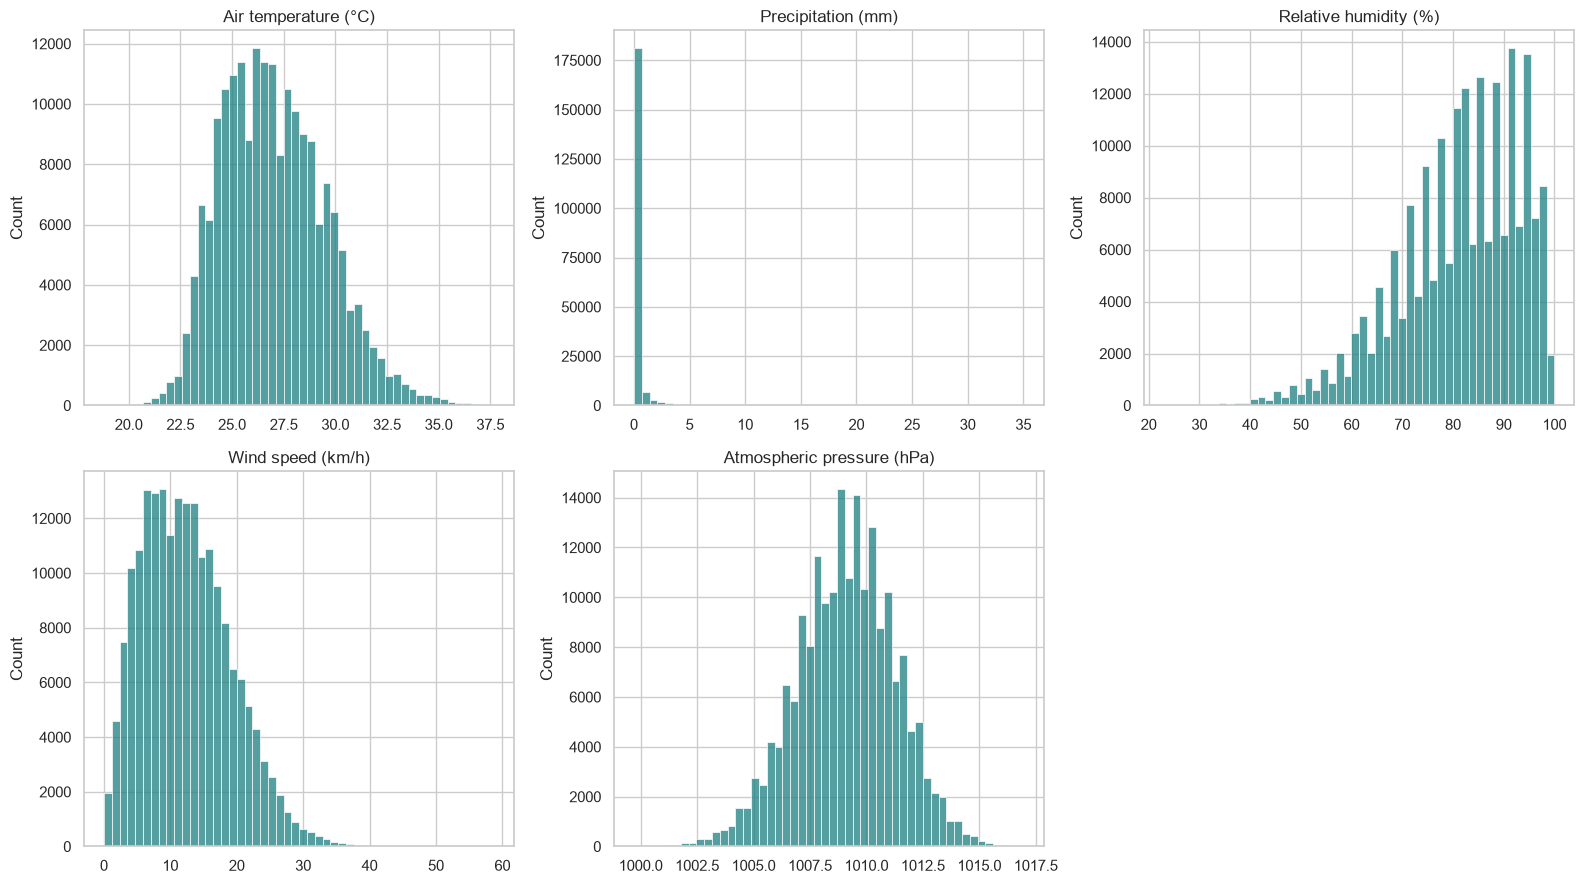

In [5]:
REQUIRED = {
    "air_temperature": "Air temperature (°C)",
    "precipitation": "Precipitation (mm)",
    "humidity": "Relative humidity (%)",
    "wind_speed": "Wind speed (km/h)",
    "atmospheric_pressure": "Atmospheric pressure (hPa)",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, label) in zip(axes.flat, REQUIRED.items()):
    sns.histplot(df[col].dropna(), bins=50, ax=ax, color="#1E7F82")
    ax.set_title(label)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


In [6]:
df[list(REQUIRED.keys())].describe().T


,count,mean,std,min,25%,50%,75%,max
air_temperature,196560.0,27.021598,2.516048,18.8,25.1,26.8,28.7,37.7
precipitation,196560.0,0.257680,0.910454,0.0,0.0,0.0,0.1,35.1
humidity,196560.0,81.321795,11.847538,23.0,74.0,83.0,91.0,100.0
wind_speed,196560.0,12.409373,6.674222,0.0,7.2,11.8,16.8,58.8
atmospheric_pressure,196560.0,1009.087614,2.195109,999.7,1007.6,1009.1,1010.6,1017.0


## 3. Monthly trends across the 18-month range

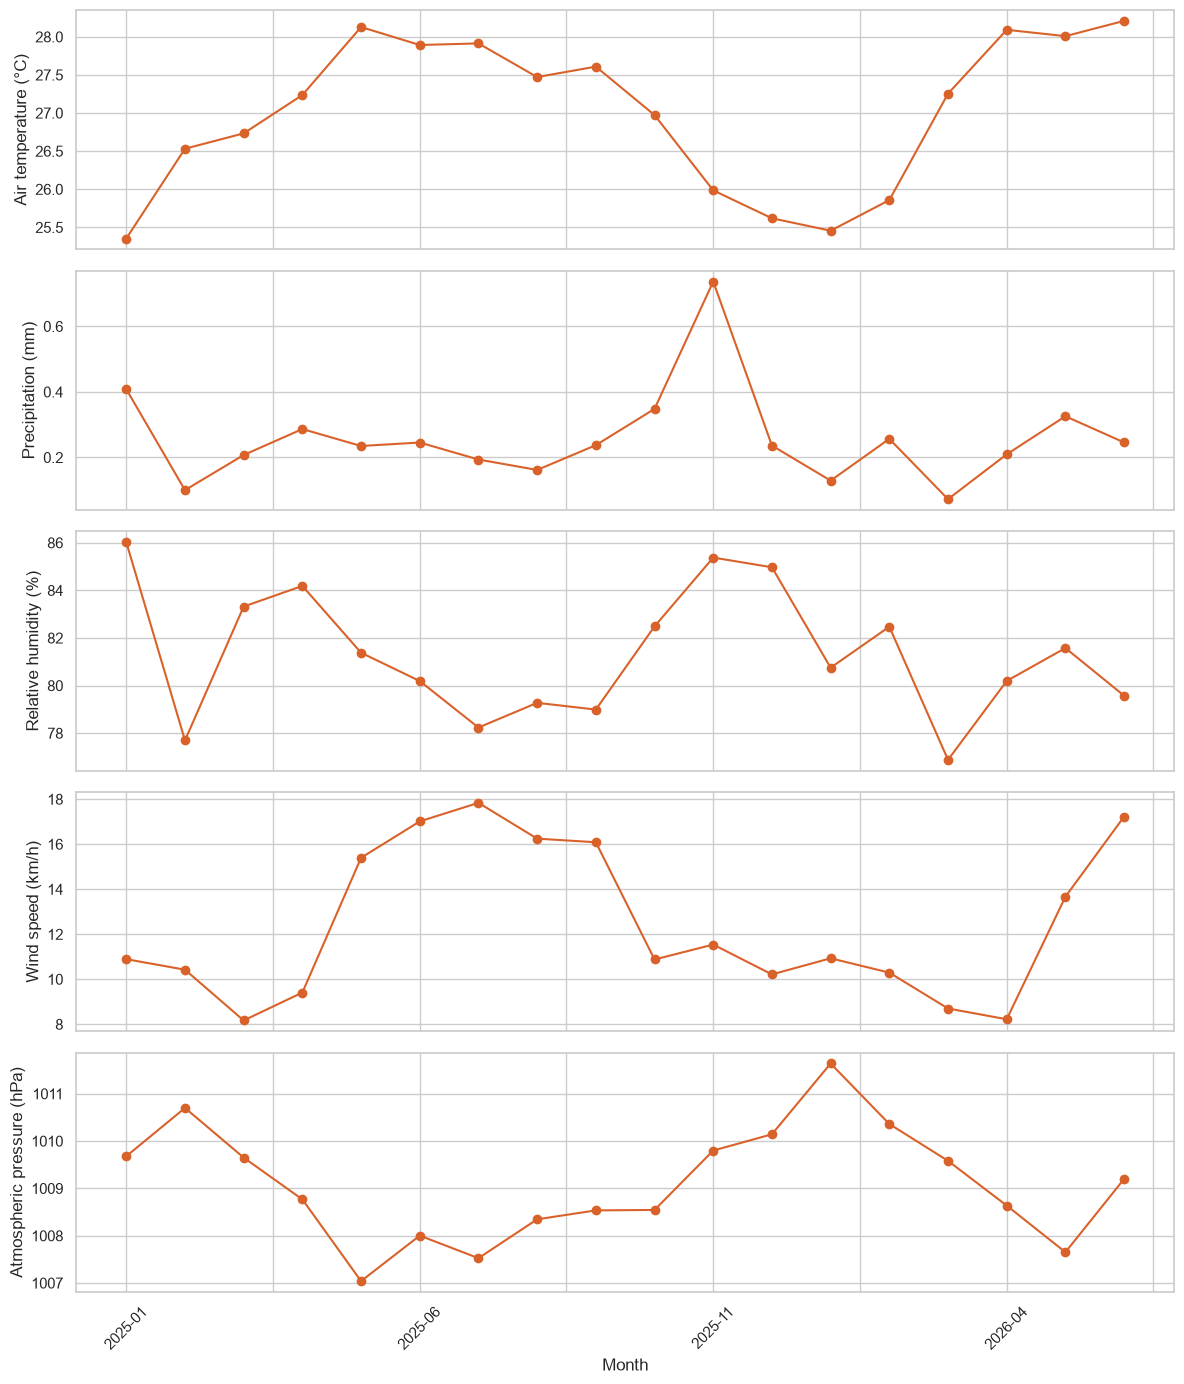

In [7]:
fig, axes = plt.subplots(len(REQUIRED), 1, figsize=(12, 14), sharex=True)
monthly = df.groupby("month")[list(REQUIRED.keys())].mean()
for ax, (col, label) in zip(axes, REQUIRED.items()):
    monthly[col].plot(ax=ax, marker="o", color="#D9622A")
    ax.set_ylabel(label)
axes[-1].set_xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Cross-location comparison

Do the 15 locations actually differ meaningfully, or is Sri Lanka's coastal
weather roughly uniform? Also checks whether the 5 TOURISM_ONLY locations
(no full marine/ocean fetch) look different on the fields they do have.

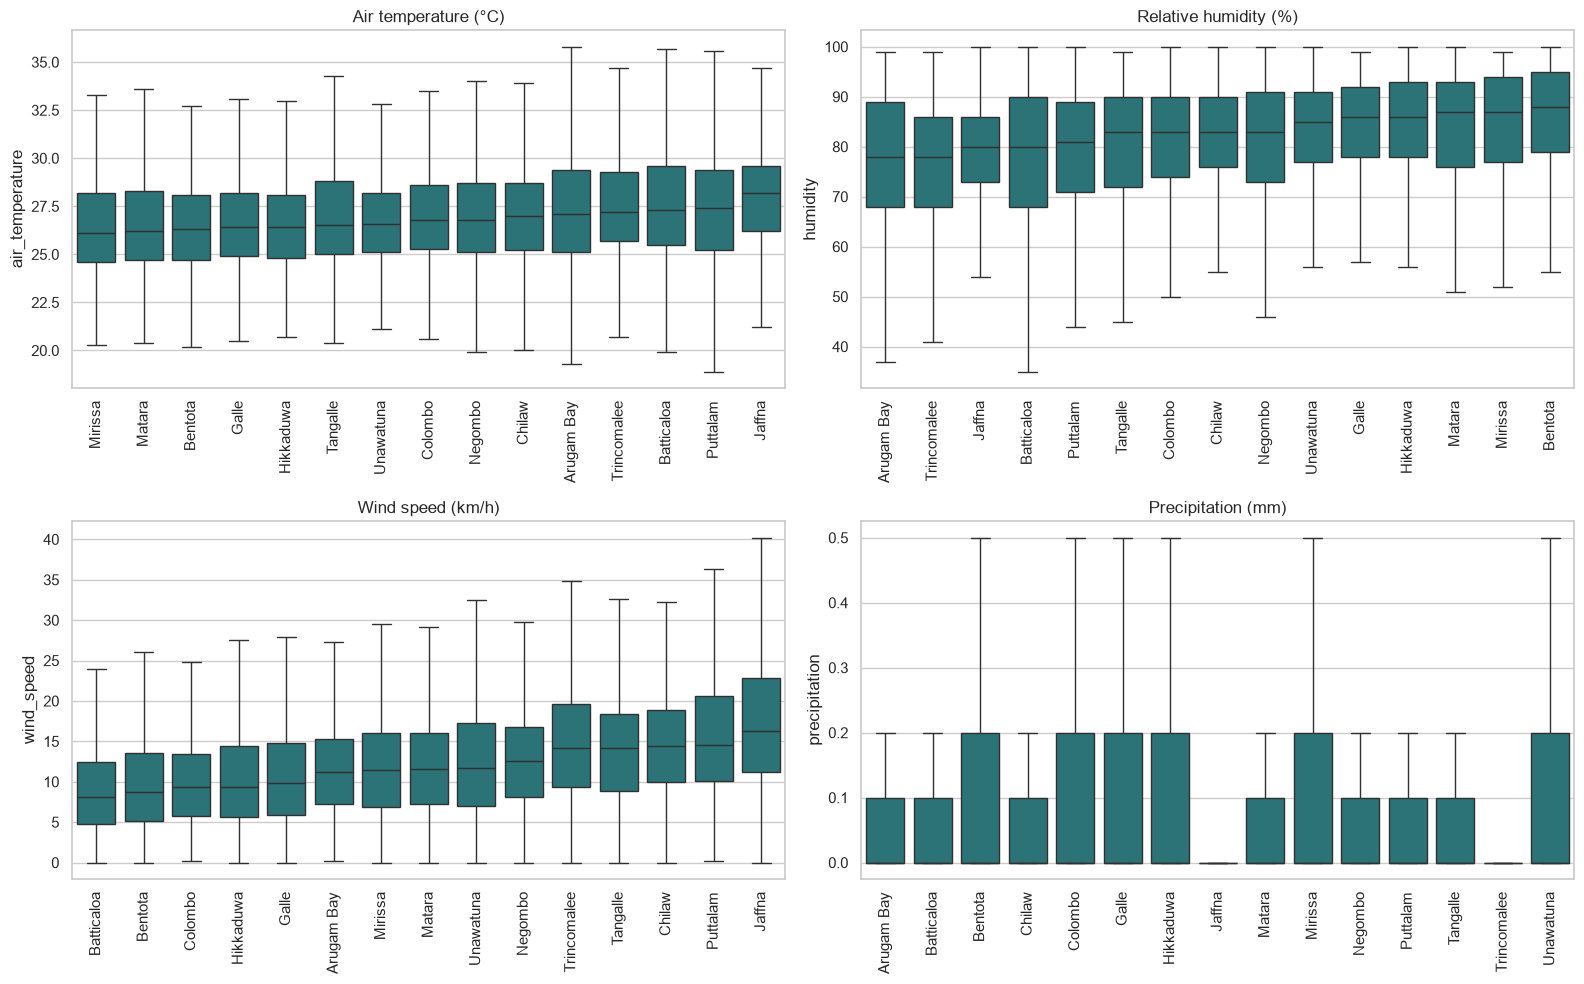

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (col, label) in zip(axes.flat, {
    "air_temperature": "Air temperature (°C)",
    "humidity": "Relative humidity (%)",
    "wind_speed": "Wind speed (km/h)",
    "precipitation": "Precipitation (mm)",
}.items()):
    order = df.groupby("location_name")[col].median().sort_values().index
    sns.boxplot(data=df, x="location_name", y=col, order=order, ax=ax, showfliers=False, color="#1E7F82")
    ax.set_title(label)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


C:\Users\MSI\AppData\Local\Temp\ipykernel_33020\765561015.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Full marine fetch (10 locations)", "Tourism-only (5 locations)"])


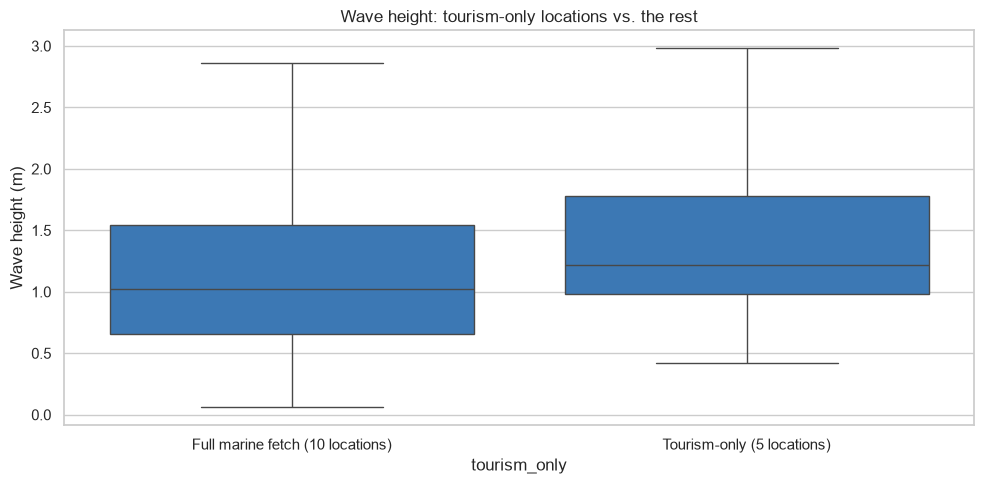

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="tourism_only", y="wave_height", ax=ax, showfliers=False, color="#2878C8")
ax.set_xticklabels(["Full marine fetch (10 locations)", "Tourism-only (5 locations)"])
ax.set_ylabel("Wave height (m)")
ax.set_title("Wave height: tourism-only locations vs. the rest")
plt.tight_layout()
plt.show()


## 5. Correlations between indicators

Where two variables move together, that's evidence for (or against) using
one as a proxy for the other in the Gold-layer suitability score or
emergency classification — rather than guessing.

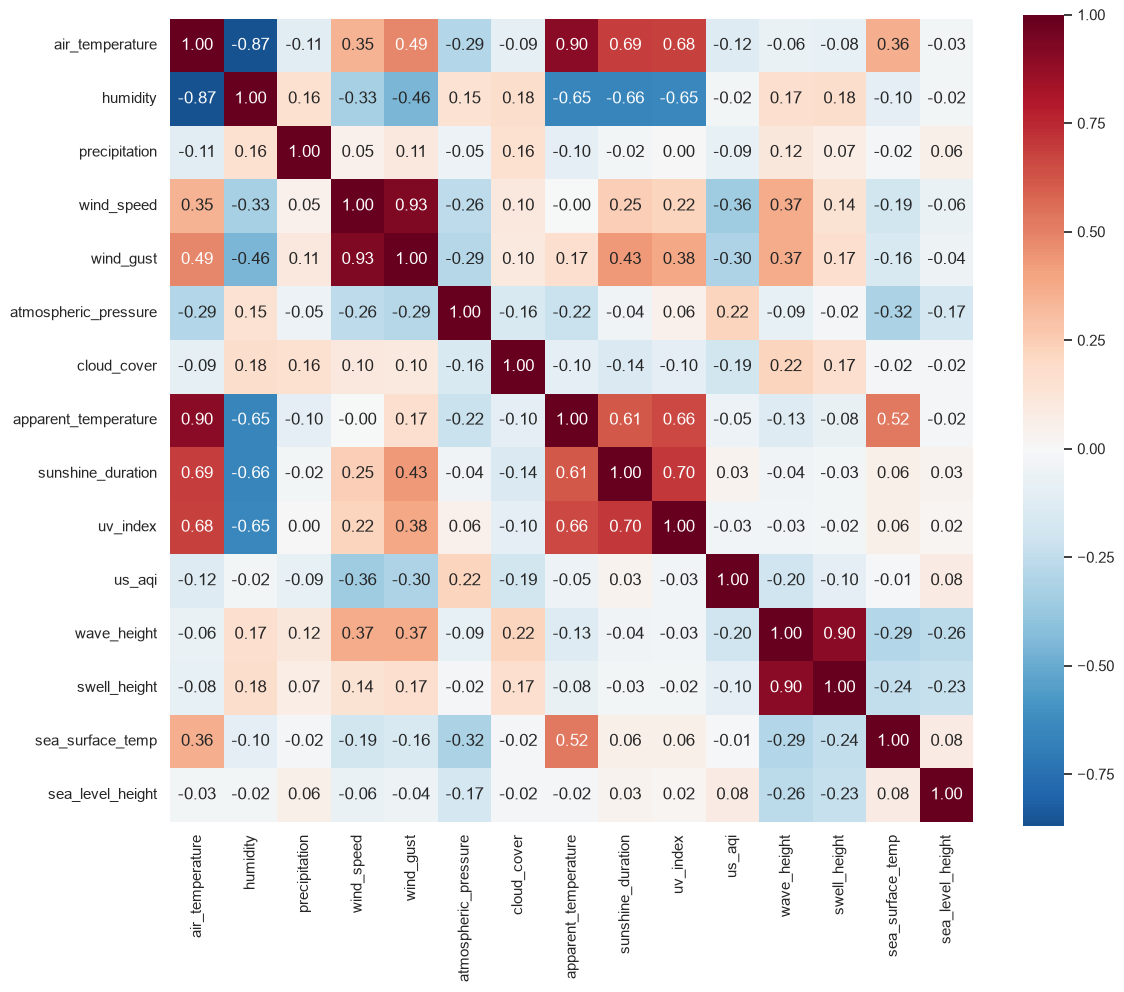

In [10]:
CORR_COLS = [
    "air_temperature", "humidity", "precipitation", "wind_speed", "wind_gust",
    "atmospheric_pressure", "cloud_cover", "apparent_temperature", "sunshine_duration",
    "uv_index", "us_aqi", "wave_height", "swell_height", "sea_surface_temp", "sea_level_height",
]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
plt.tight_layout()
plt.show()


## 6. Marine-specific indicators

Since this team's assigned direction is Marine and Coastal Weather
Analytics, wave/swell/sea-level patterns get their own closer look.

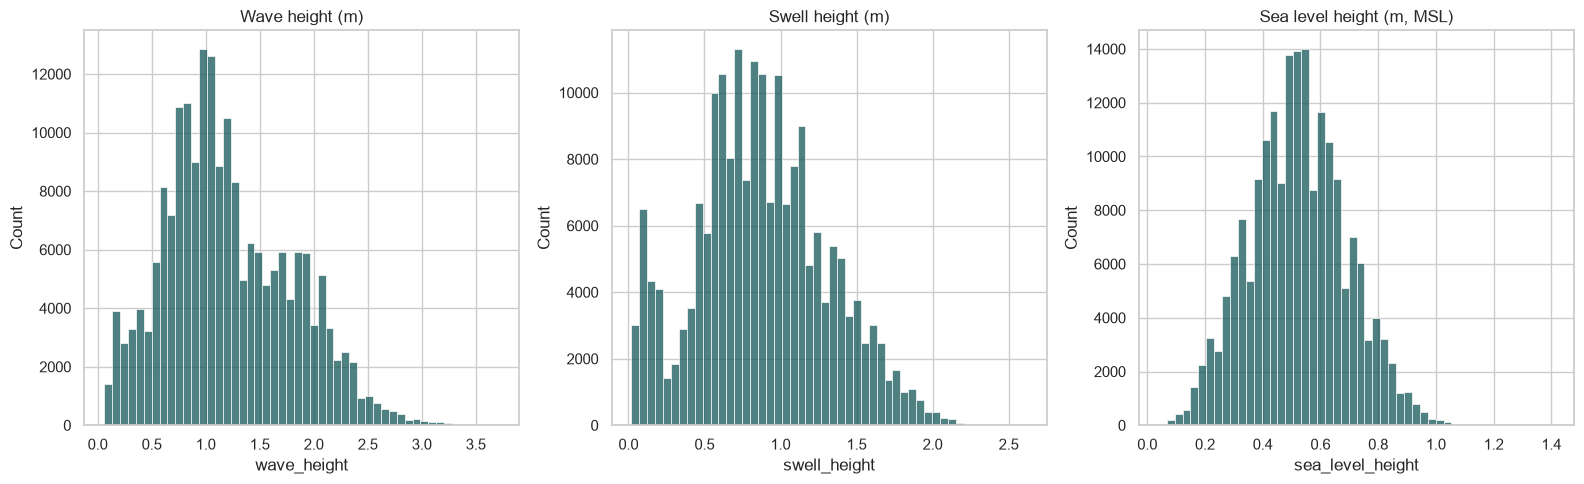

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, label) in zip(axes, {
    "wave_height": "Wave height (m)",
    "swell_height": "Swell height (m)",
    "sea_level_height": "Sea level height (m, MSL)",
}.items()):
    sns.histplot(df[col].dropna(), bins=50, ax=ax, color="#145558")
    ax.set_title(label)
plt.tight_layout()
plt.show()


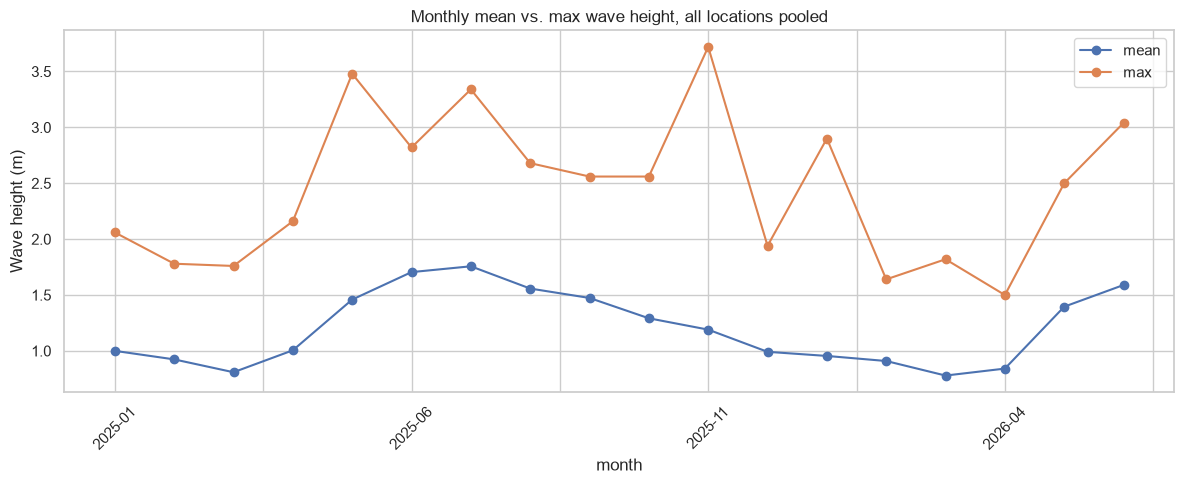

In [12]:
monthly_wave = df.groupby("month")["wave_height"].agg(["mean", "max"])
monthly_wave.plot(figsize=(12, 5), marker="o")
plt.ylabel("Wave height (m)")
plt.title("Monthly mean vs. max wave height, all locations pooled")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Gold-layer readiness checks

Four targeted follow-ups aimed specifically at informing Gold-layer design decisions, rather than general exploration.

### 7.1 Skewness of the required indicators

In [13]:
skew_table = df[["air_temperature", "precipitation", "humidity", "wind_speed", "atmospheric_pressure", "wave_height"]].skew().sort_values()
skew_table.rename("skewness").to_frame()


,skewness
humidity,-0.800808
atmospheric_pressure,-0.138665
air_temperature,0.436884
wave_height,0.482913
wind_speed,0.569759
precipitation,8.843520


**What this means for Gold aggregation choices:**

- `precipitation` (skew = 8.84) is extremely right-skewed — most hours are
  completely dry, with a small number of downpour hours pulling a long
  tail. This is exactly why `gold_tourism_daily` already uses
  `precipitation_sum` rather than a mean — a mean would be dominated by
  the rare heavy-rain hour and understate "how wet was today" on a
  typical day.
- `humidity` (skew = -0.80) is the one that's **not** right-skewed —
  it's left-skewed, consistent with a humid tropical climate where most
  hours sit near the high end (close to 100%) with a tail down toward
  occasional dry afternoons.
- `wind_speed` and `wave_height` (skew ≈ 0.5) are moderately right-skewed
  — mostly calm, occasional rough spikes — which is why Emergency's use
  of `wave_height_max` (worst-case, not average) makes sense for a safety
  framing.
- `atmospheric_pressure` (skew = -0.14) is close to symmetric, so a mean
  is a reasonable, representative daily summary for it as-is.

Conclusion: the existing Gold aggregation choices (sum for precipitation,
max for wave/wind in Emergency, mean for Tourism's other fields) already
line up with what these distribution shapes would recommend — this is
confirmation, not a needed redesign.

### 7.2 Emergency wave-height threshold calibration

In [14]:
def load_all(table, select):
    rows = []
    start = 0
    while True:
        resp = da.get_client().table(table).select(select).range(start, start + 999).execute()
        batch = resp.data
        if not batch:
            break
        rows.extend(batch)
        start += 1000
        if len(batch) < 1000:
            break
    return pd.DataFrame(rows)


gold_em = load_all("gold_emergency_daily", "classification")
print(f"Total location-days: {len(gold_em):,}")
counts = gold_em["classification"].value_counts()
pct = gold_em["classification"].value_counts(normalize=True) * 100
pd.DataFrame({"count": counts, "pct": pct.round(1)})


Total location-days: 8,190


,count,pct
classification,,
Safe,6837,83.5
Caution,1301,15.9
Dangerous,52,0.6


Across all 8,190 location-days, the current thresholds (Safe <2.0m,
Caution 2.0–3.0m, Dangerous >3.0m) produce **83.5% Safe / 15.9% Caution /
0.6% Dangerous**. This is a sensible, non-degenerate split — not
"everything is Dangerous" or "nothing is ever Caution," which would
signal badly miscalibrated cutoffs. That said, this only confirms the
thresholds produce a *plausible-looking* distribution, not that 2.0m/3.0m
are the officially correct cutoffs for actual coastal safety — that
still needs domain expert input, exactly as your project notes already
flag it ("reconstructed, not officially validated").

### 7.3 Daylight-hours-only correlation recheck

In [15]:
daylight = df[(df["hour"] >= 6) & (df["hour"] < 18)]

comparison = pd.DataFrame({
    "24h pooled": [df["cloud_cover"].corr(df["uv_index"]), df["cloud_cover"].corr(df["sunshine_duration"])],
    "daylight only (06:00-18:00)": [daylight["cloud_cover"].corr(daylight["uv_index"]), daylight["cloud_cover"].corr(daylight["sunshine_duration"])],
}, index=["cloud_cover vs uv_index", "cloud_cover vs sunshine_duration"])
comparison.round(2)


,24h pooled,daylight only (06:00-18:00)
cloud_cover vs uv_index,-0.10,-0.13
cloud_cover vs sunshine_duration,-0.14,-0.25


Restricting to daylight hours does strengthen both relationships —
`cloud_cover` vs `sunshine_duration` nearly doubles in magnitude (-0.14 →
-0.25) — supporting the idea that pooling in night hours (where UV and
sunshine are near-zero regardless of cloud cover) was diluting the
original correlation. But even restricted to daylight hours, -0.25 is
still only a weak-to-moderate relationship, not a strong one. **Honest
conclusion:** `cloud_cover` is a legitimate supplementary signal for a
"what does today look like" Tourism feature, but it shouldn't be treated
as a strong stand-in for UV index or sunshine duration — surface it
alongside them, not instead of them.

### 7.4 weather_code frequency (for a plain-language mapping)

In [16]:
WMO_LABELS = {
    0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy", 3: "Overcast",
    45: "Fog", 48: "Depositing rime fog",
    51: "Light drizzle", 53: "Moderate drizzle", 55: "Dense drizzle",
    61: "Slight rain", 63: "Moderate rain", 65: "Heavy rain",
    80: "Slight rain showers", 81: "Moderate rain showers", 82: "Violent rain showers",
    95: "Thunderstorm",
}

wc_counts = df["weather_code"].value_counts().sort_index()
wc_table = pd.DataFrame({
    "code": wc_counts.index,
    "label": [WMO_LABELS.get(c, "Unknown") for c in wc_counts.index],
    "count": wc_counts.values,
    "pct": (wc_counts.values / len(df) * 100).round(2),
})
wc_table


,code,label,count,pct
0,0,Clear sky,23212,11.81
1,1,Mainly clear,17639,8.97
2,2,Partly cloudy,13084,6.66
3,3,Overcast,71916,36.59
4,51,Light drizzle,47814,24.33
5,53,Moderate drizzle,10084,5.13
6,55,Dense drizzle,2687,1.37
7,61,Slight rain,5197,2.64
8,63,Moderate rain,4365,2.22
9,65,Heavy rain,562,0.29


Overcast (36.6%) and light drizzle (24.3%) together account for
**61% of all hours** in the dataset — this coastal weather is
predominantly cloudy/drizzly, not predominantly sunny. That's a
genuinely useful, specific fact for how Tourism should frame
`weather_code` (grouping 0–2 as "Clear/Partly cloudy," 3 as "Overcast,"
51–55 as "Drizzle," 61–65 as "Rain").

**Correction to an earlier assumption:** no thunderstorm codes (95) occur
anywhere in this dataset at all. The idea floated during EDA planning —
that `weather_code` could add a storm-risk signal to Emergency mode —
doesn't hold up against the actual data. `weather_code` is useful for
Tourism's "what does today look like" framing, not as an additional
Emergency risk signal.

## 8. Summary of findings

**Data completeness.** 196,560 hourly rows, 15 locations, zero unexpected
missingness. The only nulls are the already-documented ones: `sea_surface_temp`
/ `ocean_current_*` are null for the 5 TOURISM_ONLY locations by design (no
full marine fetch), and `sea_level_height` (3,960 rows, ~2% of the table) is
null for Jan 29 – Feb 9 2025 across *every* location equally — confirmed
directly against Open-Meteo's live API to be an upstream archive gap, not a
pipeline bug.

**Rainfall is strongly seasonal, not evenly spread.** November 2025 alone
accounts for 7,957mm of pooled precipitation — nearly double the next-wettest
month (January, 4,556mm) and roughly 4x a typical month. This lines up with
Sri Lanka's northeast monsoon (peaks Oct–Jan) rather than being noise, and
means any "typical rainfall" comparison in the dashboard should be
month-aware rather than using one flat baseline year-round.

**Temperature and wind both peak at the same location — Jaffna.** Jaffna is
both the hottest location (28.0°C mean) and the windiest (17.2 km/h mean);
Mirissa is coolest (26.4°C) despite being a southern location, and
Batticaloa is calmest for wind (9.2 km/h). Geography, not just latitude,
is driving these differences — worth keeping in mind if the Gold layer ever
compares locations against a single Sri-Lanka-wide "normal."

**Wave height has a clear seasonal swing relevant to Emergency/Tourism.**
Mean wave height peaks in July 2025 (1.76m) and troughs in March 2026
(0.78m) — more than double, consistent with the SW monsoon (roughly
May–Sept) driving rougher seas. This is a strong candidate for a
"how does this compare to typical for this month" framing, rather than the
current "compares to the full 18-month history" framing used in Emergency's
history-context sentence.

**Correlations mostly confirm the data is physically sound, with one
surprise.** `apparent_temperature` vs `air_temperature` (r=0.90) and
`wind_speed` vs `wave_height` (r=0.37, wind genuinely drives waves) and
`atmospheric_pressure` vs `wind_speed` (r=-0.26, low pressure → higher
wind, classic storm-system behavior) all move the way real meteorology
predicts — a good sanity check that the pipeline isn't misaligning data.
The surprise: `cloud_cover` barely correlates with `uv_index` (r=-0.10) or
`sunshine_duration` (r=-0.14) — both far weaker than expected. This is
likely a pooling artifact (correlating across all 24 hours including
night, when UV/sunshine are near-zero regardless of cloud cover, dilutes
the daytime relationship) rather than a real absence of the effect — a
daylight-hours-only recheck would be the natural follow-up before drawing
a firm conclusion here.

**Implication for the next phase (Gold layer).** Rainfall and wave height's
strong seasonality argues for month-aware baselines over flat ones;
`weather_code`/`cloud_cover` look genuinely useful for Tourism's "what does
it look like" framing; `apparent_temperature`'s near-1:1 relationship with
raw temperature means only one of the two is worth surfacing on the
dashboard, not both.


**Gold-layer readiness checks (Section 7) added three more concrete,
evidence-based inputs:** the existing sum/max/mean aggregation choices in
Gold already match what the distribution shapes recommend; the Emergency
wave thresholds produce a plausible (not obviously broken) Safe/Caution/
Dangerous split at 83.5/15.9/0.6%, though still not officially validated;
and `weather_code` turns out useful for Tourism's condition framing but
not as an Emergency storm signal, correcting an assumption made earlier
in this project's planning.